## 데이터 로드
-----

In [1]:
!pip install -q tf-nightly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.5/632.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 107.0 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [3]:
# 데이터 불러오기
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en', with_info=True,
                               as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/51785 [00:00<?, ? examples/s]

...

Generating validation examples...:   0%|          | 0/1193 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.7DC6OE_1.0.0/ted_hrlr_translate-val…

Generating test examples...:   0%|          | 0/1803 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/incomplete.7DC6OE_1.0.0/ted_hrlr_translate-tes…

Dataset ted_hrlr_translate downloaded and prepared to /root/tensorflow_datasets/ted_hrlr_translate/pt_to_en/1.0.0. Subsequent calls will reuse this data.
AttributeError: module 'ml_dtypes' has no attribute 'float8_e3m4'


In [4]:
# 데이터가 test, train, validation에 있음
# 이 데이터들의 형식은 tf.data.dataset 오브젝트
examples

{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>,
 Split('validation'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>,
 Split('test'): <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>}

In [5]:
type(examples['train'])

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [6]:
# train, validation, test 데이터로 나누기
train_examples, val_examples, test_examples = examples['train'], examples['validation'], examples['test']

In [7]:
import tensorflow_datasets as tfds
print(tfds.__version__)

4.9.7


In [8]:
# tfds.deprecated.text에서 SubwordTextEncoder 가져오기
SubwordTextEncoder = tfds.deprecated.text.SubwordTextEncoder

# 영어 데이터 토크나이저 생성
tokenizer_en = SubwordTextEncoder.build_from_corpus(
    (en.numpy() for pt, en in train_examples), target_vocab_size=2**13
)

# 포르투갈어 데이터 토크나이저 생성
tokenizer_pt = SubwordTextEncoder.build_from_corpus(
    (pt.numpy() for pt, en in train_examples), target_vocab_size=2**13
)


In [9]:
# 영어를 인코딩
tokenizer_en.encode("Hello man, Let's run transformer!")

[7903, 2429, 439, 406, 7345, 7907, 1283, 7870, 9, 527, 6514, 7945, 7864]

In [10]:
# 포르투갈어를 인코딩
print(tokenizer_pt.encode("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram."))

[141, 77, 33, 1566, 873, 4501, 217, 642, 4, 217, 101, 1073, 4824, 17, 5, 488, 200, 8004]


In [11]:
def encode(lang1, lang2):

  lang1 = [tokenizer_pt.vocab_size] + tokenizer_pt.encode(
      lang1.numpy()) + [tokenizer_pt.vocab_size+1] # 포르투갈 어를 인코딩 할 때 시작 단어를 의미하는 숫자와, 끝 단어를 의미하는 숫자가 붙음

  lang2 = [tokenizer_en.vocab_size] + tokenizer_en.encode(
      lang2.numpy()) + [tokenizer_en.vocab_size+1] # 영어도 마찬가지임
  return lang1, lang2

In [12]:
lang1 = tf.constant("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.", dtype=tf.string)
lang2 = tf.constant("Hello man, Let's run transformer!", dtype=tf.string)

In [13]:
print(encode(lang1, lang2))

([8214, 141, 77, 33, 1566, 873, 4501, 217, 642, 4, 217, 101, 1073, 4824, 17, 5, 488, 200, 8004, 8215], [8087, 7903, 2429, 439, 406, 7345, 7907, 1283, 7870, 9, 527, 6514, 7945, 7864, 8088])


In [14]:
# tf.py_function을 활용하여 모든 문장에 숫자를 부여함
def tf_encode(pt, en):
  result_pt, result_en = tf.py_function(encode, [pt, en], [tf.int64, tf.int64]) # 인풋 값으로 pt와 en이 한문장 한문장씩 들어가서 result_pt, result_en을 아웃풋으로 내게 됨
  result_pt.set_shape([None])
  result_en.set_shape([None])
  return result_pt, result_en

In [15]:
MAX_LENGTH = 40
BUFFER_SIZE = 60000
BATCH_SIZE = 64

# 전체 데이터에서 x가 포르투갈어 한 문장, y가 영어 한 문장인데
# 만약 문장이 인코딩 되었을 때, 인코딩 된 길이가 40을 초과하면 데이터에서 배제하고자 하는 필터 함수임
def filter_max_length(x, y, max_length=MAX_LENGTH):
  return tf.logical_and(tf.size(x) <= max_length,
                        tf.size(y) <= max_length)


In [16]:
train_dataset = train_examples.map(tf_encode) # tf_encode 함수를 활용해서 포르투갈어, 영어 각 문장에 시작 토큰과 끝 토큰을 부여함
train_dataset = train_dataset.filter(filter_max_length) # 문장의 길이가 40이 넘는 문장은 배제하고자 함
# cache the dataset to memory to get a speedup while reading from it.
train_dataset = train_dataset.cache() # cache를 활용해서 데이터를 로드할 때 빠른 처리를 기대해 봄
train_dataset = train_dataset.shuffle(BUFFER_SIZE).padded_batch(BATCH_SIZE)
# shuffle(60000) 인데, 이 말은 전체 데이터를 완전히 섞겠다는 뜻임
# 전체 데이터의 수가 50000인데 50000보다 큰 숫자를 입력하면 완전하게 전체 데이터를 섞는 것이며
# 전체 데이터 수보다 작은 수를 입력하면 전체 데이터에서 일부만 섞음
# padded_batch는 무엇이냐면, 이번 데이터셋은 문장마다 길이가 모두 다르기에
# 배치 사이즈(32) 만큼의 문장을 뽑을 때마다
# 배치 사이즈에 해당하는 만큼의 문장의 길이는 일정하게 유지됨
# 무슨 말이냐면 배치가 2개라면  이 중 하나의 문장의 길이는 37이 될 수 있고
# 두 개의 배치(32) 중 하나의 배치는 문장의 길이를 37개로 모두 유지
# 그 다음 배치에서 문장의 길이가 39 라면, 그 배치에서는 문장의 길이를 39로 유지

train_dataset = train_dataset.prefetch(tf.data.experimental.AUTOTUNE) # 데이터 로드와 처리의 시간을 overlap하여 속도 향상

val_dataset = val_examples.map(tf_encode)
val_dataset = val_dataset.filter(filter_max_length).padded_batch(BATCH_SIZE) #가변길이의 배치를 돌릴때 꼭 쓰자

## 임베딩 파트 정의
-----

In [17]:
# 먼저 포지셔널 임베딩부터
# pos / 10000 ** (2i / d_model)에 해당하는 부분을
# get_angles 함수로 출력하기

def get_angles(pos, i, d_model):
  angle_rates = 1 / np.power(10000, (2 * (i // 2) / np.float32(d_model)))
    # shape = (1, d_model)
  return np.matmul(pos, angle_rates) # pos shape : (pos, 1), angle_rates shape = (1, d_model),
                                     # np.matmul(pos, angle_rates) shape : 행렬곱 (pos,1), (1, d_model) = (pos, d_model)

def positional_encoding(position, d_model):
  angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                          np.arange(d_model)[np.newaxis, :],
                          d_model) # shape : (position, d_model)
  # 오른쪽으로 짝수번째 인덱스는 sin 함수를 적용
  angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  # 오른쪽으로 홀수번째 인덱스는 cos 함수를 적용
  angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

  pos_encoding = angle_rads[np.newaxis, ...] # pos_encoding shape : (1, position, d_model)
                                             # 왜 shape에 1을 추가해주냐면, batch_size 만큼 학습하기 위함임

  return tf.cast(pos_encoding, dtype=tf.float32)

(1, 50, 512)


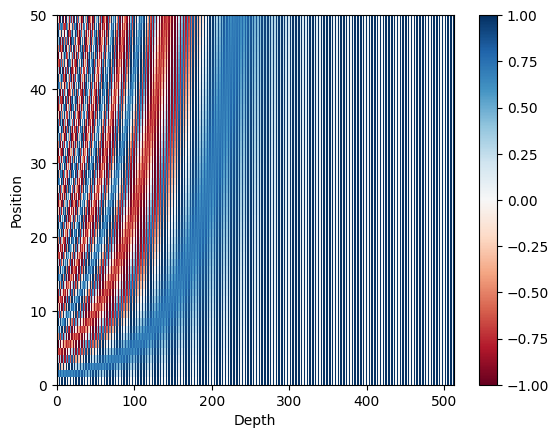

In [18]:
pos_encoding = positional_encoding(50, 512)
print(pos_encoding.shape)

plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel("Depth")
plt.xlim((0, 512))
plt.ylabel("Position")
plt.colorbar()
plt.show()

In [19]:
class TransformerEmbedding(tf.keras.layers.Layer):
  def __init__(self, d_model, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
    super().__init__()

    self.d_model = d_model # 하나의 단어가 d_model의 차원으로 인코딩 됨
    self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
     # vocab_size는 tokenizer 내부 vocab.txt의 사이즈
    self.pos_encoding = positional_encoding(maximum_position_encoding, self.d_model) # 포지셔널 인코딩
    self.dropout = tf.keras.layers.Dropout(dropout_rate) # 드롭아웃 설정


  def call(self, x, training):
    # 최초 x의 shape = (batch_size, seq_len)
    seq_len = tf.shape(x)[1]
    out = self.embedding(x) # shape : (batch_size, input_seq_len, d_model)
    out = out * tf.math.sqrt(tf.cast(self.d_model, tf.float32)) # x에 sqrt(d_model) 만큼을 곱해주냐면, 임베딩 벡터보다 포지셔널 인코딩 임베딩 벡터의 영향력을 줄이기 위해서임
                                                            # 포지셔널 인코딩은 순서만을 의미하기 때문에 임베딩 벡터보다 영향력이 적어야 이치에 맞음
    out = out + self.pos_encoding[:,:seq_len,:]
    out = self.dropout(out, training=training)


    return out # shape : (batch_size, input_seq_len, d_model)

In [20]:
x = np.float32(np.random.uniform(size=(1,40))) # 문장 길이 40
Embedder = TransformerEmbedding(512, tokenizer_en.vocab_size+2, 10000)
embedded = Embedder(x, training=False)
print(embedded) # 문장이 위치 임베딩 + 포지션 임베딩

tf.Tensor(
[[[ 0.06388299  0.9953931  -0.7168592  ...  0.3245054  -0.04438754
    0.99756855]
  [ 0.90535396  0.5356954   0.10499698 ...  0.3245054  -0.04428388
    0.99756855]
  [ 0.9731804  -0.42075375  0.2195555  ...  0.3245054  -0.04418021
    0.99756855]
  ...
  [-0.5796551   0.76080716 -1.6233768  ...  0.32449746 -0.04055201
    0.9975612 ]
  [ 0.36025155  0.95046675 -1.5802591  ...  0.32449704 -0.04044835
    0.9975608 ]
  [ 1.0276784   0.26203603 -0.7940909  ...  0.32449663 -0.04034469
    0.9975604 ]]], shape=(1, 40, 512), dtype=float32)


## 스케일드 닷 프로덕트 어텐션
-----

In [21]:
def scaled_dot_product_attention(q, k, v, mask=None):
  # q shape : (batch_size, seq_len, d_model)
  # k shape : (batch_size, seq_len, d_model)
  # v shape : (batch_size, seq_len, d_model)
  matmul_qk = tf.matmul(q, k, transpose_b = True)
  #matmul_qk shape : (batch_size, seq_len, seq_len)

  dk = tf.cast(tf.shape(k)[-1], tf.float32)
  scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

  # scaled_attetion_logits shape : (batch_size, seq_len, seq_len)

  if mask is not None:
    scaled_attention_logits = scaled_attention_logits + (mask * -1e9)

  softmax = tf.nn.softmax(scaled_attention_logits, axis=-1)

  # softmax shape : (batch_size, seq_len, seq_len)

  output = tf.matmul(softmax, v)

  # output(attention_value) shape : (batch_size, seq_len, d_model)
  # 즉 처음 입력 차원인 (batch_size, seq_len, d_model) 차원을 아웃풋으로 반환

  return output, softmax

In [22]:
q = tf.cast(np.random.uniform(size=(1,2,512)), dtype=tf.float32)
k = tf.cast(np.random.uniform(size=(1,7,512)), dtype=tf.float32)
v = tf.cast(np.random.uniform(size=(1,7,512)), dtype=tf.float32)
scaled_dot_product_attention(q,k,v)

(<tf.Tensor: shape=(1, 2, 512), dtype=float32, numpy=
 array([[[0.5850426 , 0.7780584 , 0.47933942, ..., 0.5870982 ,
          0.5077468 , 0.44651255],
         [0.5869793 , 0.7852647 , 0.47761312, ..., 0.6005387 ,
          0.5068515 , 0.44177014]]], dtype=float32)>,
 <tf.Tensor: shape=(1, 2, 7), dtype=float32, numpy=
 array([[[0.13432457, 0.17965032, 0.10652845, 0.11354748, 0.16625209,
          0.14247341, 0.15722361],
         [0.13315342, 0.16496512, 0.09516415, 0.10460363, 0.17009807,
          0.1534545 , 0.17856105]]], dtype=float32)>)

## 멀티 헤드 어텐션 정의
-----

In [23]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.wq = tf.keras.layers.Dense(d_model)
    self.wk = tf.keras.layers.Dense(d_model)
    self.wv = tf.keras.layers.Dense(d_model)

    self.dense = tf.keras.layers.Dense(d_model)

  def split_heads(self, x, batch_size):
    x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
    return tf.transpose(x, perm=[0,2,1,3])

  def call(self, v, k, q, mask):
    batch_size = tf.shape(q)[0]

    q = self.wq(q)
    k = self.wk(k)
    v = self.wv(v)

    q = self.split_heads(q, batch_size)
    k = self.split_heads(k, batch_size)
    v = self.split_heads(v, batch_size)


    attention_weights, softmax = scaled_dot_product_attention(q, k, v, mask)

    scaled_attention = tf.transpose(attention_weights, perm=[0,2,1,3])

    concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

    output = self.dense(concat_attention)

    return output, softmax

In [24]:
q = tf.cast(np.random.uniform(size=(1,2,512)), dtype=tf.float32)
k = tf.cast(np.random.uniform(size=(1,7,512)), dtype=tf.float32)
v = tf.cast(np.random.uniform(size=(1,7,512)), dtype=tf.float32)
temp_mha = MultiHeadAttention(512, 8)
encoder_output, _ = temp_mha(v,k,q, mask=None)
print(encoder_output)

tf.Tensor(
[[[-0.7370014   0.8031068   0.8113579  ...  0.26452297  0.08765721
   -0.46695563]
  [-0.7293219   0.8130913   0.8024644  ...  0.2697567   0.09483234
   -0.46295616]]], shape=(1, 2, 512), dtype=float32)


## 포인트와이즈 피드 포워드 네트워크 정의
-----

In [25]:
class Pointwise_FeedForward_Network(tf.keras.layers.Layer):
  def __init__(self, d_model, dff):
    super().__init__()
    self.d_model = d_model
    self.dff = dff

    self.middle = tf.keras.layers.Dense(dff, activation='relu')
    self.out = tf.keras.layers.Dense(d_model)

  def call(self, x):
    middle = self.middle(x) # middle shape : (batch_size, seq_len, dff)
    out = self.out(middle) # out shape : (batch_size, seq_len, d_model)
    return out

In [26]:
sample_PFFN = Pointwise_FeedForward_Network(512, 2048)
sample_PFFN(encoder_output)

<tf.Tensor: shape=(1, 2, 512), dtype=float32, numpy=
array([[[-0.06827204, -0.11114669,  0.12427903, ...,  0.12023877,
         -0.08761159,  0.05410113],
        [-0.07946955, -0.11050189,  0.1214773 , ...,  0.12600198,
         -0.08569989,  0.04472722]]], dtype=float32)>

## 인코더, 디코더 정의
-----

In [27]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super().__init__()
    self.mha = MultiHeadAttention(d_model, num_heads)
    self.ffn = Pointwise_FeedForward_Network(d_model, dff)

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

  def call(self, x, training, mask=None):
    # x : 위치 임베딩 + 단어 임베딩 된 인코딩의 인풋
    attn_output, _ = self.mha(x, x, x, mask)
    # 멀티헤드 어텐션
    # attn_output shape : (batch_size, input_seq_len, d_model)

    attn_output = self.dropout1(attn_output, training=training)

    out1 = self.layernorm1(x + attn_output) # Residual Network 거침, 레이어 노멀레이제이션을 통한 값 평준화

    ffn_output = self.ffn(out1) # ffn_output_shape : (batch_size, input_seq_len, d_model), 포인트와이즈 피드포워드 네트워크
    ffn_output = self.dropout2(ffn_output, training=training)

    out2 = self.layernorm2(out1 + ffn_output)   # Residual Network 거침
                                                # out2 shape : (batch_size, input_seq_len, d_model)

    return out2

In [28]:
# 임베딩
x = np.float32(np.random.uniform(size=(1,40))) # 문장 길이 40
Embedder = TransformerEmbedding(512, tokenizer_en.vocab_size+2, 10000)
embedded = Embedder(x, training=False)
print(embedded) # 문장이 위치 임베딩 + 포지션 임베딩
#인코더
sample_encoder = EncoderLayer(d_model=512, num_heads=8, dff=2048, rate=0.1)
sample_encoding = sample_encoder(embedded, training=None, mask=None)
print(sample_encoding)
#최종출력
print("Encoded 차원 :", sample_encoding.shape)

tf.Tensor(
[[[-0.61632556  0.4784537  -0.7247496  ...  1.5395635  -0.6038795
    1.1190734 ]
  [ 0.2251454   0.01875597  0.09710658 ...  1.5395635  -0.60377586
    1.1190734 ]
  [ 0.29297185 -0.9376931   0.2116651  ...  1.5395635  -0.6036722
    1.1190734 ]
  ...
  [-1.2598636   0.24386775 -1.6312673  ...  1.5395555  -0.60004395
    1.1190661 ]
  [-0.319957    0.43352735 -1.5881495  ...  1.5395552  -0.5999403
    1.1190656 ]
  [ 0.3474698  -0.25490338 -0.80198133 ...  1.5395548  -0.59983665
    1.1190653 ]]], shape=(1, 40, 512), dtype=float32)
tf.Tensor(
[[[-0.06701463  0.56704885 -0.3445614  ...  0.4973398  -0.7079946
   -0.25630352]
  [ 0.5140615   0.139158    0.31110495 ...  0.52788174 -0.7327922
   -0.3696713 ]
  [ 0.5445508  -0.6289107   0.40525582 ...  0.69366044 -0.6506397
   -0.42264983]
  ...
  [-0.33110848  0.55149424 -1.1204334  ...  1.0010409  -0.5153177
   -0.24991271]
  [ 0.3109684   0.732303   -0.9695312  ...  0.98500025 -0.56524307
   -0.2826137 ]
  [ 0.85709405  0.2268

In [29]:
# 상삼각행렬 만들기
tf.linalg.band_part(tf.ones((10, 10)), -1, 0)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float32)>

In [30]:
temp_mask = 1 - tf.linalg.band_part(tf.ones((40, 40)), -1, 0)
print(temp_mask)

tf.Tensor(
[[0. 1. 1. ... 1. 1. 1.]
 [0. 0. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(40, 40), dtype=float32)


In [31]:
# 예제 문장 (1, 40) 즉, 1문장, 40개의 단어를 가짐
example_sentence = np.hstack([np.random.randint(20, size=10), np.zeros(30)])[np.newaxis, :]
print(example_sentence) # 예제 문장
example_sentence = tf.cast(tf.math.equal(example_sentence, 0), dtype=tf.float32)
print(example_sentence) # 패딩 된 것(문장에서 0이 아닌 부분은 0으로, 0인 부분은 1로)
example_sentence = example_sentence[:, tf.newaxis, tf.newaxis, :] # 차원 변경
print(example_sentence)

look_ahead_mask = tf.maximum(temp_mask, example_sentence) # 상삼각행렬과 example sentence를 비교해가며 최대값만 취해서 패딩을 1로 처리함
# look ahead mask
print(look_ahead_mask)

[[10. 13. 18.  9.  9. 14. 16. 16. 18.  1.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.]]
tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]], shape=(1, 40), dtype=float32)
tf.Tensor(
[[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
    1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]]], shape=(1, 1, 1, 40), dtype=float32)
tf.Tensor(
[[[[0. 1. 1. ... 1. 1. 1.]
   [0. 0. 1. ... 1. 1. 1.]
   [0. 0. 0. ... 1. 1. 1.]
   ...
   [0. 0. 0. ... 1. 1. 1.]
   [0. 0. 0. ... 1. 1. 1.]
   [0. 0. 0. ... 1. 1. 1.]]]], shape=(1, 1, 40, 40), dtype=float32)


In [32]:
# look_ahead_mask 알아보기
def create_look_ahead_mask(size):
  mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
  return mask

def create_masks(tar):
  temp_mask = create_look_ahead_mask(tf.shape(tar)[1])


  reverse_tar = tf.cast(tf.math.equal(tar, 0), dtype=tf.float32)
  reverse_tar = reverse_tar[:,tf.newaxis,tf.newaxis,:]
  look_ahead_mask = tf.maximum(reverse_tar, temp_mask)


  return look_ahead_mask

In [33]:
def create_padding_mask(seq):
  seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
  return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

In [34]:
example_sentence = np.hstack([np.random.randint(20, size=10), np.zeros(30)])[np.newaxis, :]
# 패딩 되기 전
print(example_sentence)
# 패딩 된 후
print(create_padding_mask(example_sentence))

[[18.  8. 17. 11. 16. 13.  3. 12.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.]]
tf.Tensor(
[[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
    1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]]], shape=(1, 1, 1, 40), dtype=float32)


In [35]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, rate=0.1):
    super().__init__()

    self.mha1 = MultiHeadAttention(d_model, num_heads)
    self.mha2 = MultiHeadAttention(d_model, num_heads)

    self.ffn = Pointwise_FeedForward_Network(d_model, dff)

    self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
    self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    self.dropout1 = tf.keras.layers.Dropout(rate)
    self.dropout2 = tf.keras.layers.Dropout(rate)
    self.dropout3 = tf.keras.layers.Dropout(rate)


  def call(self, x, enc_output, training, padding_mask, look_ahead_mask):
    # x : 훈련 과정에서는 Seq2Seq에서 번역이 될 문장이 입력됨,
    # x : 추론 과정에서는 과거의 단어가 입력됨
    # enc_output : 인코더의 출력
    # padding_mask : 멀티 헤드 어텐션에 필요한 정보만 남기고 나머지는 패딩 처리
    # look_ahead_mask : 위에 설명
    # enc_output_shape == (batch_size, input_seq_len, d_model)

    #### 첫번째 멀티 헤드 어텐션 파트임 ####
    #### 첫번째 멀티 헤드 어텐션은, 인코더와의 결합 없이 번역이 될 문장끼리만 어텐션을 함 ####
    attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask)
    out1 = self.dropout1(attn1, training=training)
    out1 = self.layernorm1(out1 + x)

    #### 두번째 멀티 헤드 어텐션 파트임 ####
    #### 두번째 멀티 헤드 어텐션 파트는 enc_output에서 인코더와(포르투갈어), out1(영어문장으로만 셀프어텐션을 한 것)
    #### 이 다시 멀티 헤드 어텐션 과정을 거치게 됨
    #### 다시 상기하자면, 이번 과제는 포르투갈 어를 영어로 번역하는 것임
    attn2, attn_weights_block2 = self.mha2(
        enc_output, enc_output, out1, padding_mask)
    out2 = self.dropout2(attn2, training=training)
    out2 = self.layernorm2(out2 + out1) # (batch_size, target_seq_len, d_model)


    ffn_output = self.ffn(out2)
    ffn_output = self.dropout3(ffn_output, training=training)
    out3 = self.layernorm3(ffn_output + out2) # (batch_size, target_seq_len, d_model)


    return out3, attn_weights_block1, attn_weights_block2

In [36]:
sample_decoder_layer = DecoderLayer(d_model=512, num_heads=8, dff=2048)
sample_decoder_layer_output, _, _ = sample_decoder_layer(
    embedded, sample_encoding, training=False, look_ahead_mask=None, padding_mask=None
)
print(sample_decoder_layer_output)
print(sample_decoder_layer_output.shape)

tf.Tensor(
[[[ 1.2940165  -0.4591598  -1.5729462  ...  0.47511956 -0.44969246
   -1.0118523 ]
  [ 1.7320157  -0.8297261  -1.2139295  ...  0.39630336 -0.44019684
   -1.017534  ]
  [ 1.8129506  -1.4039667  -1.1126224  ...  0.36125207 -0.3889417
   -1.0197841 ]
  ...
  [ 1.375657   -0.72749084 -1.8419119  ...  0.4308495  -0.4880773
   -0.8891976 ]
  [ 1.8522255  -0.62311065 -1.8878869  ...  0.44169825 -0.5688218
   -0.8458982 ]
  [ 2.1499407  -0.9009174  -1.4583429  ...  0.42730343 -0.6525821
   -0.8037192 ]]], shape=(1, 40, 512), dtype=float32)
(1, 40, 512)


In [37]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, rate=0.1):
        super(Encoder, self).__init__()
        self.num_layers = num_layers
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)
        ]
        self.dropout = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        x = self.dropout(x, training=training)  # Dropout에 training을 전달
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)  # training을 키워드 인자로 전달
        return x


In [38]:
Encoder_layer = Encoder(6, 512, 8, 2048)  # 6층, 512차원의 단어 임베딩, 8개의 병렬 멀티 헤드 어텐션의 인코더
# embedded : 위치 임베딩 + 단어 임베딩
Encoded = Encoder_layer(embedded, training=False, mask=None)
print(Encoded)
print(Encoded.shape)

tf.Tensor(
[[[-1.0742289   0.3538427  -3.0718277  ... -1.6671854   1.9383621
   -1.1071053 ]
  [-1.018348    0.34083605 -3.0344286  ... -1.6463383   1.912419
   -1.0966897 ]
  [-0.96495104  0.30740726 -3.0607293  ... -1.6264508   1.9045868
   -1.1126001 ]
  ...
  [-0.873254    0.3070185  -3.2006347  ... -1.5382321   1.7793247
   -1.1456333 ]
  [-0.81979144  0.3213709  -3.1758482  ... -1.5191792   1.7749012
   -1.1669803 ]
  [-0.80656356  0.31886697 -3.1248667  ... -1.5140705   1.7590882
   -1.165669  ]]], shape=(1, 40, 512), dtype=float32)
(1, 40, 512)


In [39]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, rate=0.1):
        super(Decoder, self).__init__()
        self.num_layers = num_layers
        self.dec_layers = [
            DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)
        ]
        self.dropout = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask=None, padding_mask=None):
        attention_weights = {}

        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](
                x,
                enc_output,
                training=training,  # 수정된 부분
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask
            )
            attention_weights[f'decoder_layer{i+1}_block1'] = block1
            attention_weights[f'decoder_layer{i+1}_block2'] = block2

        return x, attention_weights


In [40]:
# 위치 임베딩 + 포지셔널 임베딩
embedded
#인코더 아웃풋
Encoded

# 디코더의 위치+포지셔널 임베딩(Teaching Force 과정이라 디코더 부분에 타겟(영어)도 넣어줌)
target_embedder = TransformerEmbedding(d_model=512, input_vocab_size=tokenizer_en.vocab_size, maximum_position_encoding=512, dropout_rate=0.1)
target_embedding = target_embedder(
    tf.cast(np.random.uniform(size=(1, 40)), dtype=tf.float32),
    training=True
)

# 6층 디코더
Decoder_layer = Decoder(num_layers=6, d_model=512, num_heads=8, dff=2048)

Decoded, _ = Decoder_layer(
    target_embedding,
    Encoded,
    training=False,
    look_ahead_mask=None,
    padding_mask=None
)

print(Decoded, Decoded.shape)
#최종출력
print("6층 Decoder 출력 :", sample_encoding.shape)


tf.Tensor(
[[[-0.18003663  0.23449983  0.27161404 ...  1.2287643   1.7301663
   -0.76976377]
  [-0.18788701  0.22120051  0.28654507 ...  1.2296665   1.7215707
   -0.7809011 ]
  [-0.17695814  0.21196096  0.28662392 ...  1.2194215   1.7358603
   -0.7753199 ]
  ...
  [-0.18925737  0.22077285  0.26354066 ...  1.2461677   1.732253
   -0.77861714]
  [-0.1827565   0.2315951   0.25985974 ...  1.2521553   1.7407031
   -0.7735297 ]
  [-0.1857352   0.21884423  0.26527196 ...  1.2402316   1.7408202
   -0.7891843 ]]], shape=(1, 40, 512), dtype=float32) (1, 40, 512)
6층 Decoder 출력 : (1, 40, 512)


## 임베딩 + 인코딩 + 디코딩을 결합하는 Transformer Class 정의
-----

In [41]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, pe_input, pe_target, rate=0.1):
        super().__init__()
        self.input_embedder = TransformerEmbedding(d_model, input_vocab_size, pe_input, rate)
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, rate)
        self.target_embedder = TransformerEmbedding(d_model, target_vocab_size, pe_target, rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, rate)
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inp, tar, training=False, **kwargs):  # **kwargs 추가
        # inp: 포르투갈어 입력, tar: 영어 입력
        enc_mask = create_padding_mask(inp)
        dec_mask = create_padding_mask(inp)
        look_ahead_mask = create_masks(tar)

        inp_embedding = self.input_embedder(inp, training=training)
        enc_output = self.encoder(inp_embedding, training=training, mask=enc_mask)

        tar_embedding = self.target_embedder(tar, training=training)
        dec_output, attention_weights = self.decoder(
            tar_embedding, enc_output, training=training, padding_mask=dec_mask, look_ahead_mask=look_ahead_mask
        )

        final_output = self.final_layer(dec_output)
        return final_output


In [42]:
# 트랜스포머 테스트하기
sample_transformer = Transformer(
    num_layers=6, d_model=512, num_heads=8, dff=2048,
    input_vocab_size=tokenizer_pt.vocab_size + 2,
    target_vocab_size=tokenizer_en.vocab_size + 2,
    pe_input=10000, pe_target=10000
)

inp = tf.cast(np.random.randint(100, size=(1, 40)), dtype=tf.int32)
tar = tf.cast(np.random.randint(100, size=(1, 40)), dtype=tf.int32)

transformer_output = sample_transformer(inp, tar, training=False)
print(transformer_output)


tf.Tensor(
[[[ 0.5056818   0.580085    0.12092777 ... -0.05438075 -0.07204729
    0.45906305]
  [ 0.5289566   0.5806491   0.11832241 ... -0.07934424 -0.0698712
    0.4677947 ]
  [ 0.52602077  0.58233654  0.11713786 ... -0.07432759 -0.06523227
    0.46136466]
  ...
  [ 0.54120237  0.61269027  0.07962675 ... -0.06825037 -0.0329856
    0.5033666 ]
  [ 0.5407681   0.6167035   0.07809749 ... -0.06763072 -0.03535318
    0.50258094]
  [ 0.5405089   0.62060076  0.08731519 ... -0.05976756 -0.02404596
    0.49774536]]], shape=(1, 40, 8089), dtype=float32)


## 하이퍼파라미터 설정하기
-----

In [43]:
num_layers = 4    # 4층 인코더, 디코더 쌓기
d_model = 128   # 단어의 임베딩 차원을 128로
dff = 512  # 포인트와이즈 피드포워드 네트워크의 일시적인 차원을 512
num_heads = 8 # 멀티 헤드 어텐션을 8개로 병렬 처리
SEQ_LEN = 40

input_vocab_size = tokenizer_pt.vocab_size + 2
target_vocab_size = tokenizer_en.vocab_size + 2
dropout_rate = 0.1

## 옵티마이저 설정하기
-----

In [51]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        self.d_model = d_model
        self.d_model = tf.cast(self.d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float32로 변환
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)

        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

learning_rate = CustomSchedule(d_model)


optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

## Loss 함수 설정하기
-----

In [52]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none') #from_logits=True로 하면 Dense 이후 softmax layer 값 출력

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0)) # 예를 들어서 실제 자료(0은 패딩)가 [1,2,3,4,5,0,0,0,0,0] 이라면 [0,0,0,0,0,1,1,1,1,1]로 바꿔 줌
                                                     # 이후 tf.math.logical_not을 활용해서 [True,True,True,True,True,False,False,False,False,False]으로 바꿔 줌
  loss_ = loss_object(real, pred) # loss_는 패딩을 고려하지 않은 loss 값

  mask = tf.cast(mask, dtype=loss_.dtype) # [True,True,True,True,True,False,False,False,False,False]를 [1,1,1,1,1,0,0,0,0,0] 으로 바꿔 줌
  loss_ *= mask # loss에 mask를 곱해서, 패딩인 부분은 0처리 해줌

  return tf.reduce_sum(loss_)/tf.reduce_sum(mask)

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

## 모델 훈련
-----

In [53]:
transformer = Transformer(num_layers, d_model, num_heads, dff,
                          input_vocab_size, target_vocab_size,
                          pe_input=10000,
                          pe_target=10000,
                          rate=0.1)

In [54]:
# 인풋, 아웃풋의 텐셔 shape 정의
train_step_signature = [
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),
]

# tf.function을 사용하면 그래프를 미리 컴파일 하기 때문에 속도가 상당히 빠름
# 같은 GPU여도 케라스에 비해서 체감상 7~8배 정도의 차이가 나는 것 같음
@tf.function(input_signature=train_step_signature)
def train_step(inp, tar):
    tar_inp = tar[:, :-1]
    tar_real = tar[:, 1:]

    with tf.GradientTape() as tape:
        # `training=True`를 키워드 인자로 전달
        predictions = transformer(inp, tar_inp, training=True)
        loss = loss_function(tar_real, predictions)

    gradients = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

    train_loss(loss)
    train_accuracy(tar_real, predictions)

In [55]:
# 저장할 체크포인트 지정
checkpoint_path = "./"

ckpt = tf.train.Checkpoint(transformer=transformer,
                           optimizer=optimizer)

ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# if a checkpoint exists, restore the latest checkpoint.
if ckpt_manager.latest_checkpoint:
  ckpt.restore(ckpt_manager.latest_checkpoint)
  print ('Latest checkpoint restored!!')

In [56]:
for inp, tar in train_dataset.take(1):
    print(inp.shape, tar.shape)  # 텐서의 크기 확인
    print(inp, tar)             # 일부 데이터 샘플 출력

(64, 40) (64, 40)
tf.Tensor(
[[8214   42 1239 ...    0    0    0]
 [8214   25  257 ...    0    0    0]
 [8214 2981 5096 ...    0    0    0]
 ...
 [8214   67   92 ...    0    0    0]
 [8214 1352 4057 ...    0    0    0]
 [8214  192  822 ...    0    0    0]], shape=(64, 40), dtype=int64) tf.Tensor(
[[8087   16  344 ...    0    0    0]
 [8087   23   51 ...    0    0    0]
 [8087  154 1918 ...    0    0    0]
 ...
 [8087   94  119 ...    0    0    0]
 [8087  201   17 ...    0    0    0]
 [8087   18   12 ...    0    0    0]], shape=(64, 40), dtype=int64)


In [57]:
predictions = transformer(inp, tar[:, :-1], training=True)
print(predictions.shape)  # 예상 출력: (batch_size, seq_len, vocab_size)

(64, 39, 8089)


In [58]:
import time
# 20 에포크 훈련
for epoch in range(20):
  start = time.time()

  train_loss.reset_state()
  train_accuracy.reset_state()

  # input : 포루투갈어, tar : 영어
  for (batch, (inp, tar)) in enumerate(train_dataset):
    train_step(inp, tar)

    if batch % 50 == 0:
      print ('Epoch {} Batch {} Loss {:.4f} Accuracy {:.4f}'.format(
          epoch + 1, batch, train_loss.result(), train_accuracy.result()))

  if (epoch + 1) % 5 == 0:
    ckpt_save_path = ckpt_manager.save()
    print ('Saving checkpoint for epoch {} at {}'.format(epoch+1,
                                                         ckpt_save_path))

  print ('Epoch {} Loss {:.4f} Accuracy {:.4f}'.format(epoch + 1,
                                                train_loss.result(),
                                                train_accuracy.result()))

  print ('Time taken for 1 epoch: {} secs\n'.format(time.time() - start))

Epoch 1 Batch 0 Loss 9.0035 Accuracy 0.0004
Epoch 1 Batch 50 Loss 8.9399 Accuracy 0.0046
Epoch 1 Batch 100 Loss 8.8443 Accuracy 0.0159
Epoch 1 Batch 150 Loss 8.7436 Accuracy 0.0197
Epoch 1 Batch 200 Loss 8.6188 Accuracy 0.0215
Epoch 1 Batch 250 Loss 8.4651 Accuracy 0.0239
Epoch 1 Batch 300 Loss 8.2900 Accuracy 0.0291
Epoch 1 Batch 350 Loss 8.1047 Accuracy 0.0329
Epoch 1 Batch 400 Loss 7.9228 Accuracy 0.0360
Epoch 1 Batch 450 Loss 7.7570 Accuracy 0.0387
Epoch 1 Batch 500 Loss 7.6088 Accuracy 0.0417
Epoch 1 Batch 550 Loss 7.4722 Accuracy 0.0452
Epoch 1 Batch 600 Loss 7.3446 Accuracy 0.0488
Epoch 1 Batch 650 Loss 7.2230 Accuracy 0.0522
Epoch 1 Batch 700 Loss 7.1089 Accuracy 0.0555
Epoch 1 Loss 7.1046 Accuracy 0.0556
Time taken for 1 epoch: 61.84154200553894 secs

Epoch 2 Batch 0 Loss 5.6338 Accuracy 0.0925
Epoch 2 Batch 50 Loss 5.4446 Accuracy 0.1045
Epoch 2 Batch 100 Loss 5.3950 Accuracy 0.1081
Epoch 2 Batch 150 Loss 5.3510 Accuracy 0.1103
Epoch 2 Batch 200 Loss 5.3039 Accuracy 0.1120
Ep

## 평가
-----

In [59]:
def evaluate(inp_sentence):
    # 시작 토큰과 끝 토큰 추가
    start_token = [tokenizer_pt.vocab_size]
    end_token = [tokenizer_pt.vocab_size + 1]

    # 포르투갈어 문장에 시작/끝 토큰 추가
    inp_sentence = start_token + tokenizer_pt.encode(inp_sentence) + end_token
    encoder_input = tf.expand_dims(inp_sentence, 0)

    # 디코더 입력의 시작: 영어 시작 토큰
    decoder_input = [tokenizer_en.vocab_size]
    output = tf.expand_dims(decoder_input, 0)

    for i in range(MAX_LENGTH):
        # Transformer 모델 호출 시 `training=False`를 키워드 인자로 전달
        predictions = transformer(encoder_input, output, training=False)

        # 예측 결과에서 마지막 단어 추출
        predictions = predictions[:, -1:, :]  # (batch_size, 1, vocab_size)
        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        # 영어 끝 토큰을 예측하면 종료
        if predicted_id == tokenizer_en.vocab_size + 1:
            return tf.squeeze(output, axis=0)

        # 예측된 단어를 디코더 입력에 추가
        output = tf.concat([output, predicted_id], axis=-1)

    return tf.squeeze(output, axis=0)


In [60]:
def translate(sentence):
    result = evaluate(sentence)

    # 번역 결과 디코딩
    predicted_sentence = tokenizer_en.decode([i for i in result if i < tokenizer_en.vocab_size])

    print('Input: {}'.format(sentence))
    print('Predicted translation: {}'.format(predicted_sentence))


In [61]:
translate("este é um problema que temos que resolver.")
print("Real translation: this is a problem we have to solve.")

Input: este é um problema que temos que resolver.
Predicted translation: this is a problem that we have to solve it .
Real translation: this is a problem we have to solve.


In [62]:
translate("os meus vizinhos ouviram sobre esta ideia.")
print ("Real translation: and my neighboring homes heard about this idea .")

Input: os meus vizinhos ouviram sobre esta ideia.
Predicted translation: my neighbors heard about this idea .
Real translation: and my neighboring homes heard about this idea .


In [63]:
translate("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.")
print ("Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .")

Input: vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Predicted translation: so i 'm going to share with you a lot of magic stories that have happened to you on it .
Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .


In [64]:
translate("este é o primeiro livro que eu fiz.")
print ("Real translation: this is the first book i've ever done.")

Input: este é o primeiro livro que eu fiz.
Predicted translation: this is the first book i did n't........... to do that .
Real translation: this is the first book i've ever done.


출처
https://github.com/kimwoonggon/publicservant_AI/blob/master/%EC%8B%AC%ED%99%942_%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8_%EC%89%BD%EA%B2%8C%EA%B5%AC%ED%98%84%ED%95%B4%EB%B3%B4%EA%B8%B0.ipynb